In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [2]:
import torch
from custom_vision_transformer import vit_custom
from training_utils import get_data_loaders
from types import SimpleNamespace
import matplotlib.pyplot as plt

In [3]:
params = SimpleNamespace(
    gpu_idx=0,
    num_classes=100,
    img_size=224,
    batch_size=16,
)

In [4]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 3


/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU2 Quadro P400 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
Quadro P400 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Quadro P400 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


Device: cuda:0 NVIDIA GeForce RTX 2080


In [5]:
model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, attention_bias=True).to(device)
checkpoint = torch.load("./training_checkpoints/checkpoint1/vit_custom_epoch_85.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval();

In [28]:
train_loader, val_loader = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

imgs, labels = next(iter(val_loader))
tensor = imgs[0].unsqueeze(0).to(device)  # add batch dimension and move to device

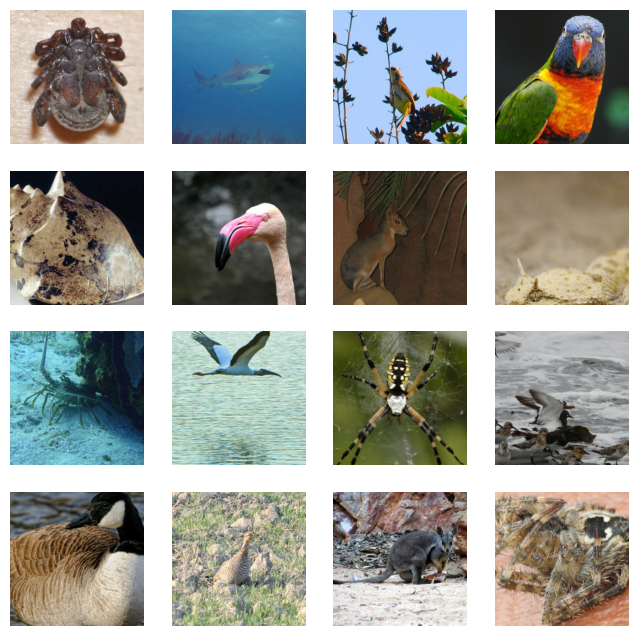

In [29]:
# display some images
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
sample_imgs = imgs[:16]  # take first 16 images
sample_imgs = sample_imgs.cpu().permute(0, 2, 3, 1) * torch.tensor(std).view(1, 1, 1, 3) + torch.tensor(mean).view(1, 1, 1, 3)
sample_imgs = torch.clamp(sample_imgs, 0, 1).numpy()
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.axis('off')
plt.show()

In [30]:
activations = {
    "b": {},
    "attn": {}
}

# --- Fonctions hook ---
def make_b_hook(name):
    def hook(module, input, output):
        activations["b"][name] = output.detach()
    return hook

def make_attn_hook(name):
    def hook(module, input, output):
        out, attn = output
        activations["attn"][name] = attn.detach()
    return hook

# --- Nettoyer tous les hooks existants sur tous les modules ---
for module in model.modules():
    module._forward_hooks.clear()

# --- Ajouter les hooks ---
for name, module in model.named_modules():
    if name.endswith(".attention.b"):
        module.register_forward_hook(make_b_hook(name))
    elif name.endswith(".attention"):
        module.register_forward_hook(make_attn_hook(name))

In [31]:
_ = model(tensor.to(device))

In [32]:
for k, v in activations["attn"].items():
    print(k, v.shape)

for k, v in activations["b"].items():
    print(k, v.shape)

encoder.layers.encoder_layer_0.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_1.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_2.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_3.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_4.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_5.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_6.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_7.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_8.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_9.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_10.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_11.attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_0.attention.b torch.Size([1, 197, 6])
encoder.layers.encoder_layer_1.attention.b torch.Size([1, 197, 6])
encoder.layers.encoder_l

In [33]:
attention_list = [v for k, v in activations["attn"].items()]
b_list = [v for k, v in activations["b"].items()]

In [34]:
# --- attention map of all layers averaged across heads ---
attentions_avg = [attn.mean(dim=1) for attn in attention_list]  # average over heads
for i in range(len(attentions_avg)):
    plt.imshow(attentions_avg[i][0].cpu())
    plt.savefig(f"attention_maps/attention_maps_imgs/attention_map_{i}")
    plt.close()

In [35]:
num_layer = 8
attention_at_layer = attention_list[num_layer][0]
b_at_layer = b_list[num_layer][0]

In [36]:
# --- attention map of all heads from layer num_layer --- (only works if average_attn_weights=False in new_forward)
output_dir = f"attention_maps/attention_maps_all_heads_layer{num_layer}"
os.makedirs(output_dir, exist_ok=True)
for i in range(len(attention_at_layer)):
    plt.imshow(attention_at_layer[i,:,:].cpu())
    plt.savefig(f"{output_dir}/attention_map_{i}")
    plt.close()

In [37]:
# --- attention bias map of all heads from layer num_layer ---
output_dir = f"attention_maps/attention_biases_all_heads_layer{num_layer}"
os.makedirs(output_dir, exist_ok=True)
for head in range(b_at_layer.shape[-1]):
    tensor = b_at_layer[:, head].view(1, -1)
    tensor = torch.softmax(tensor, dim=-1)
    img = tensor.repeat(b_at_layer.shape[0], 1).cpu().numpy()
    plt.imshow(img)
    plt.savefig(f"{output_dir}/bias_map_{head}")
    plt.close()

In [38]:
print(b_at_layer.shape)
print(attention_at_layer.shape)

torch.Size([197, 6])
torch.Size([6, 197, 197])


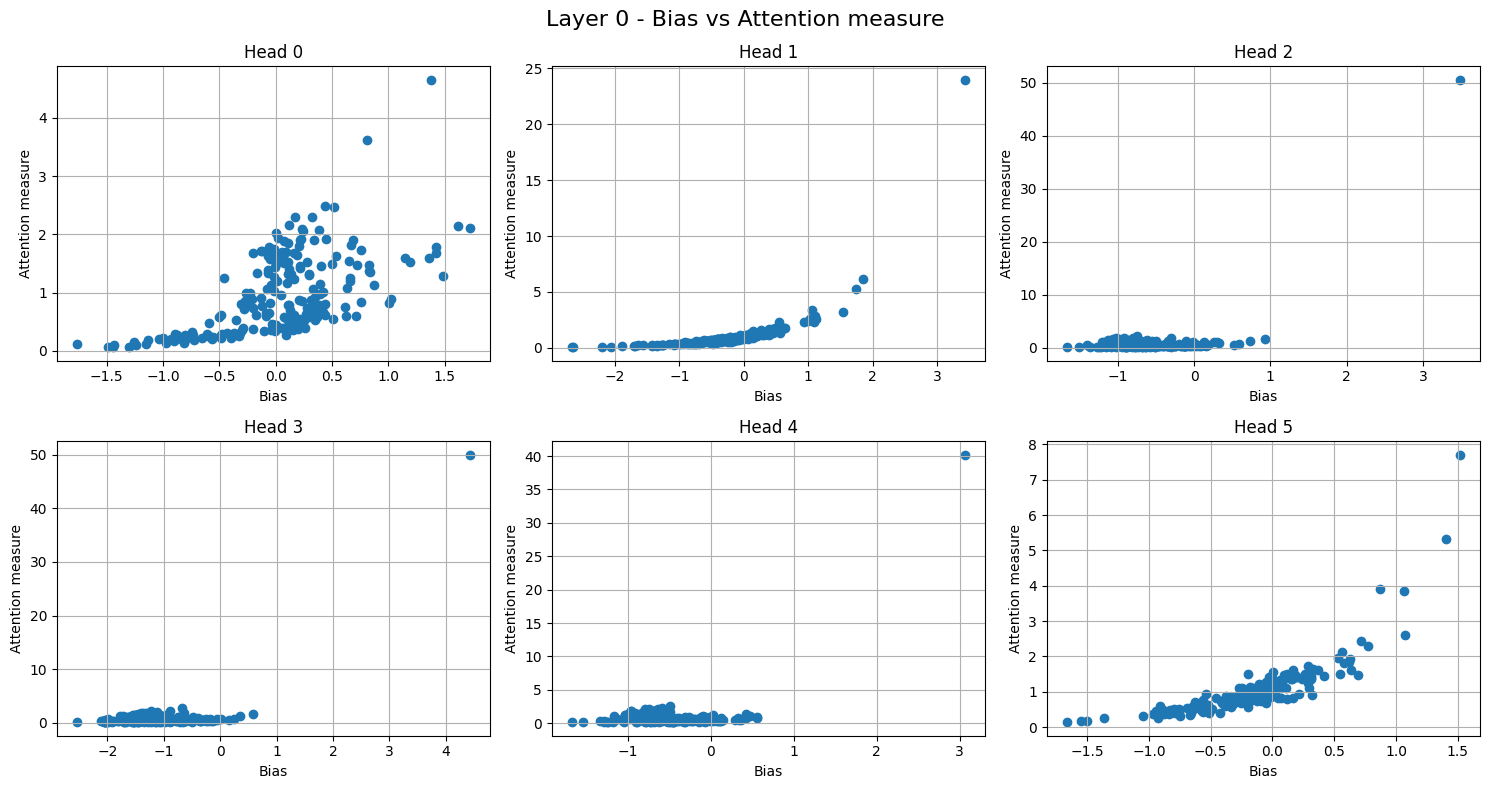

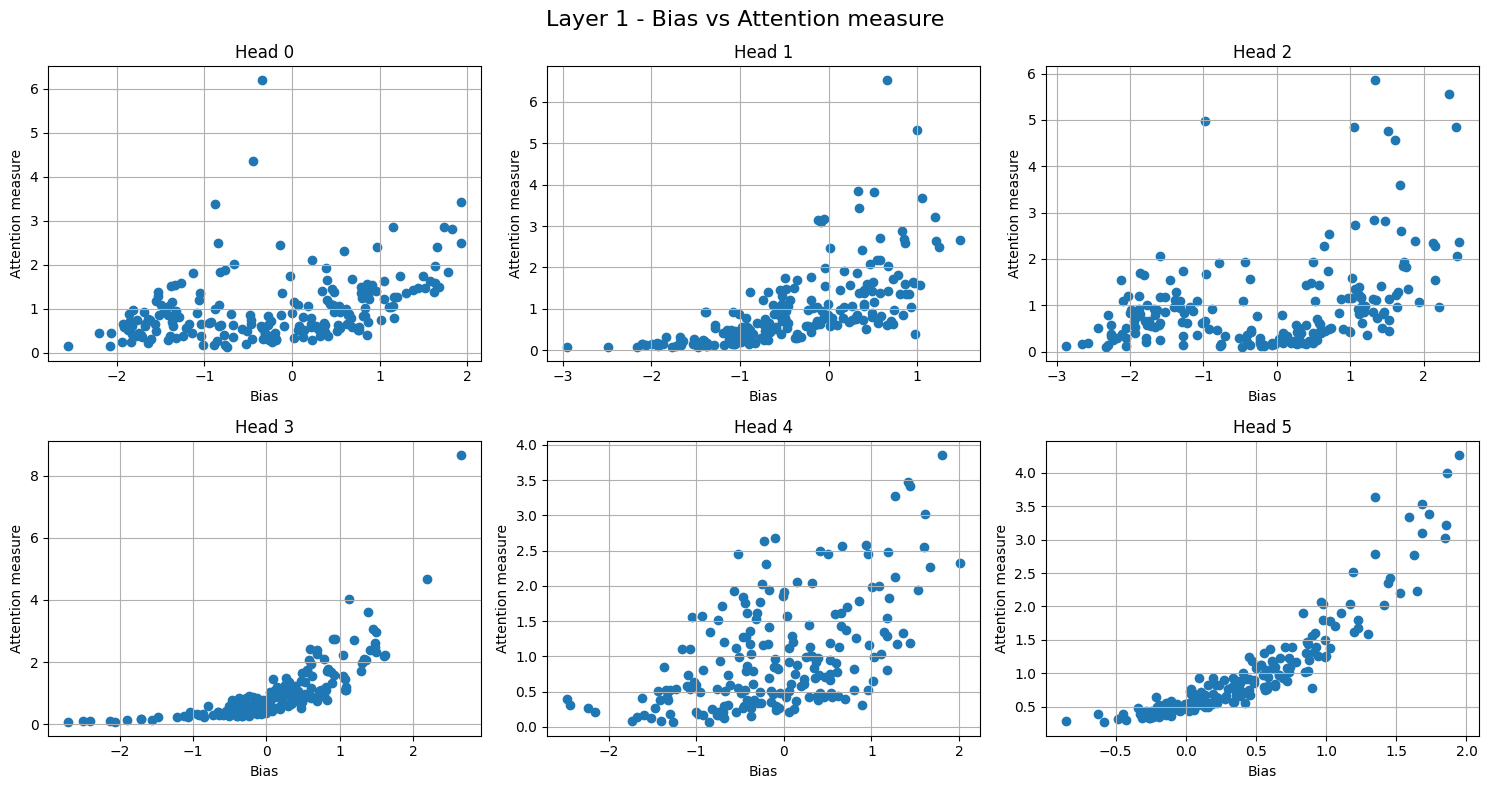

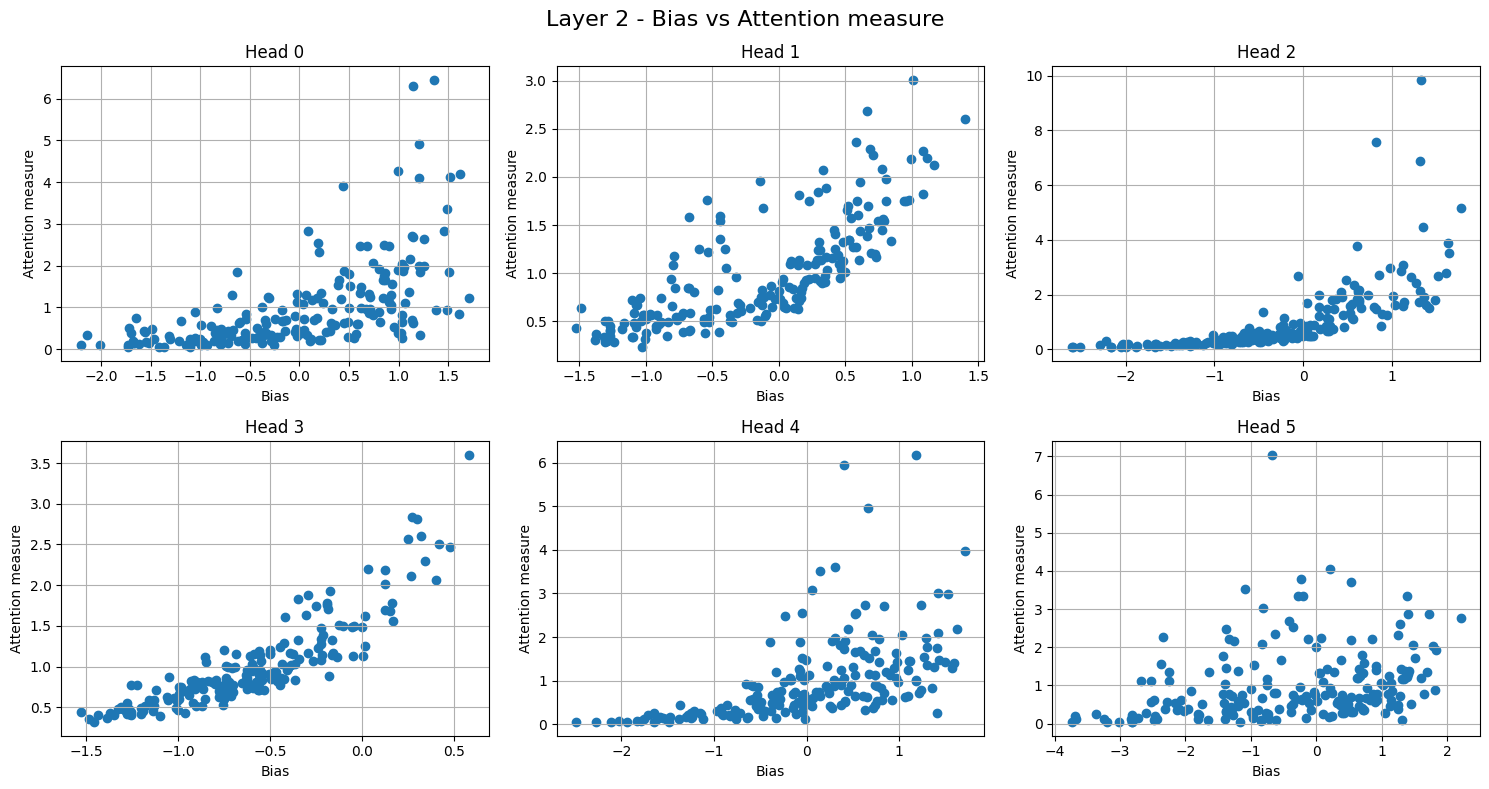

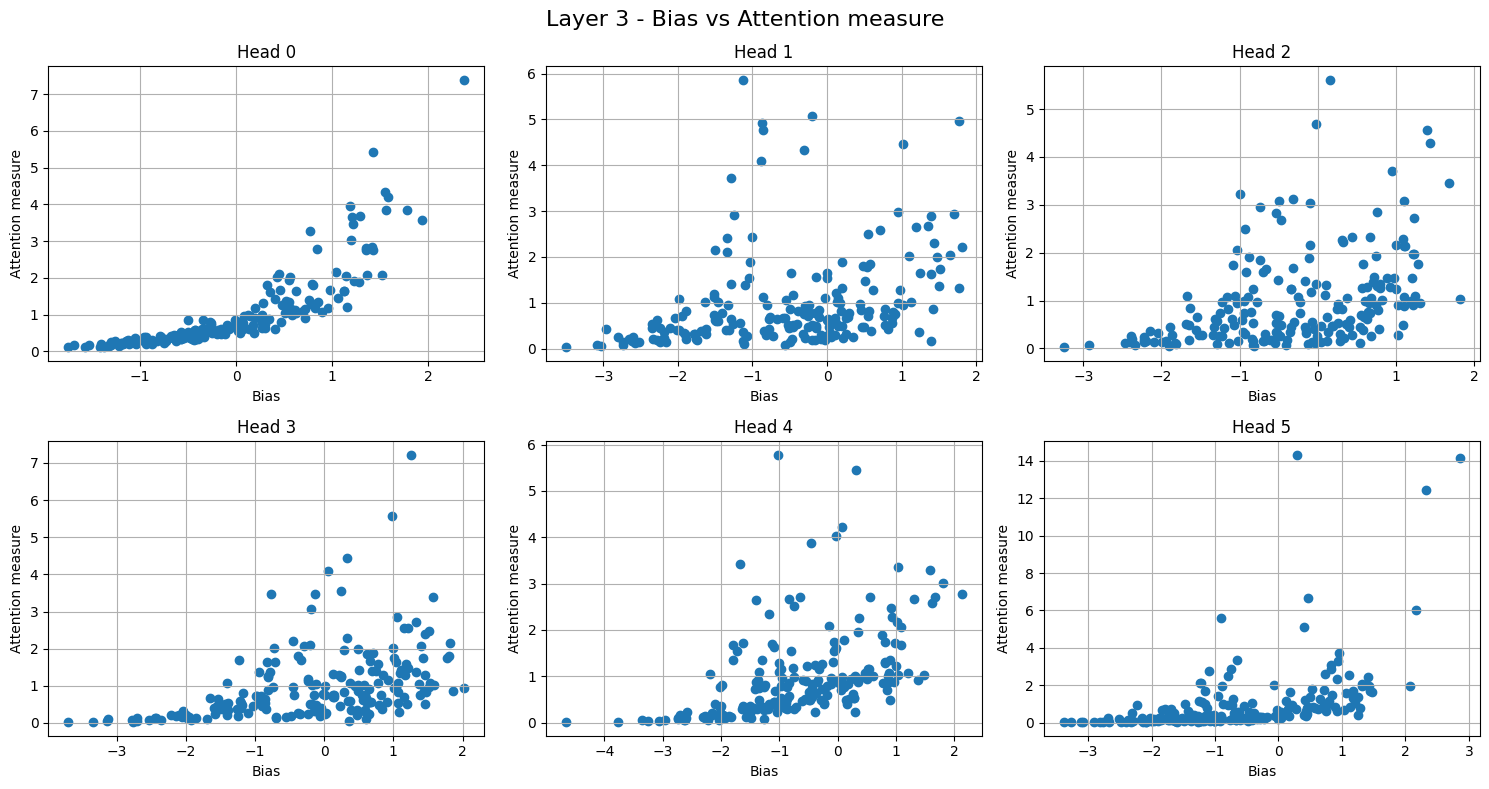

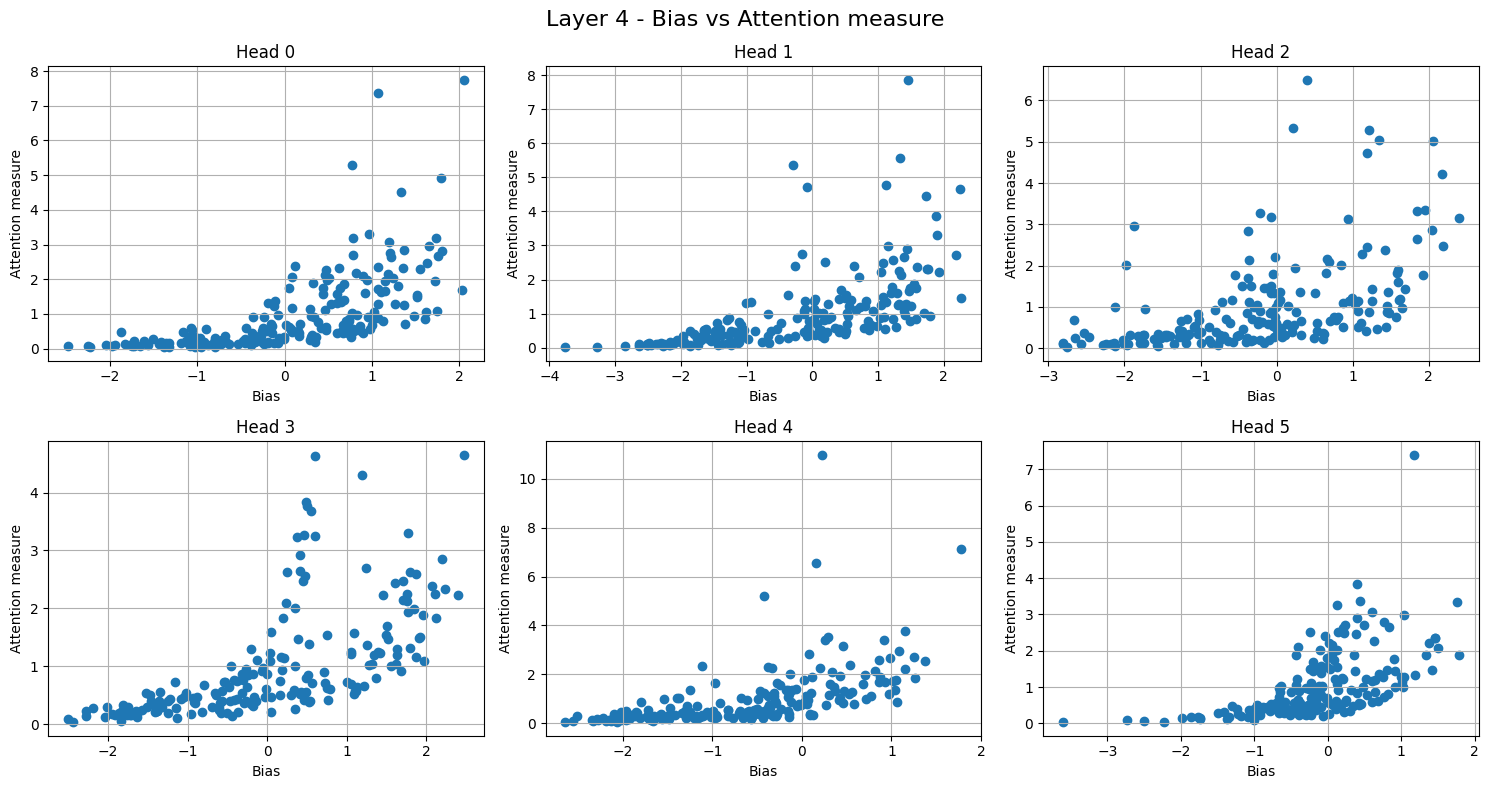

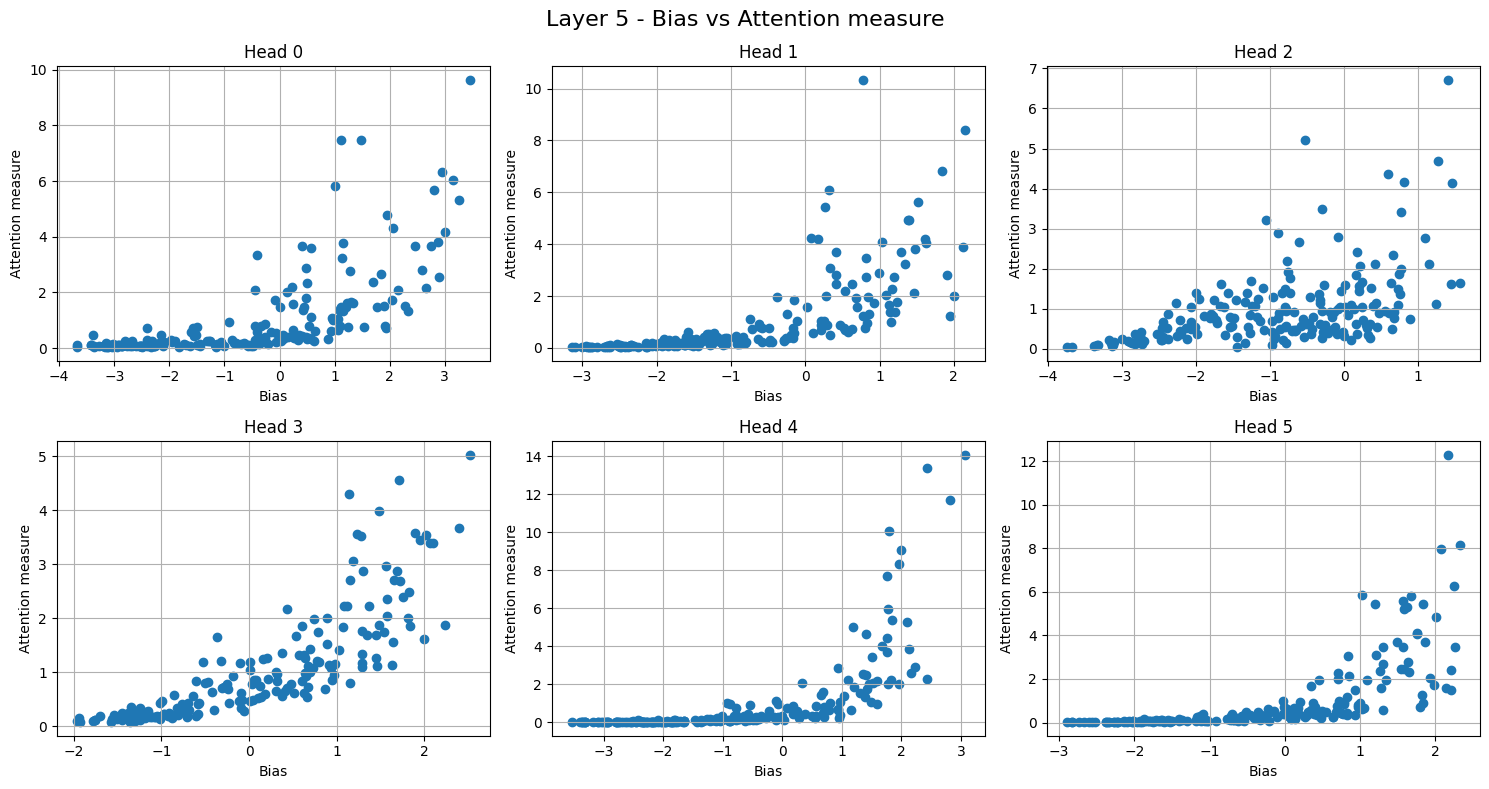

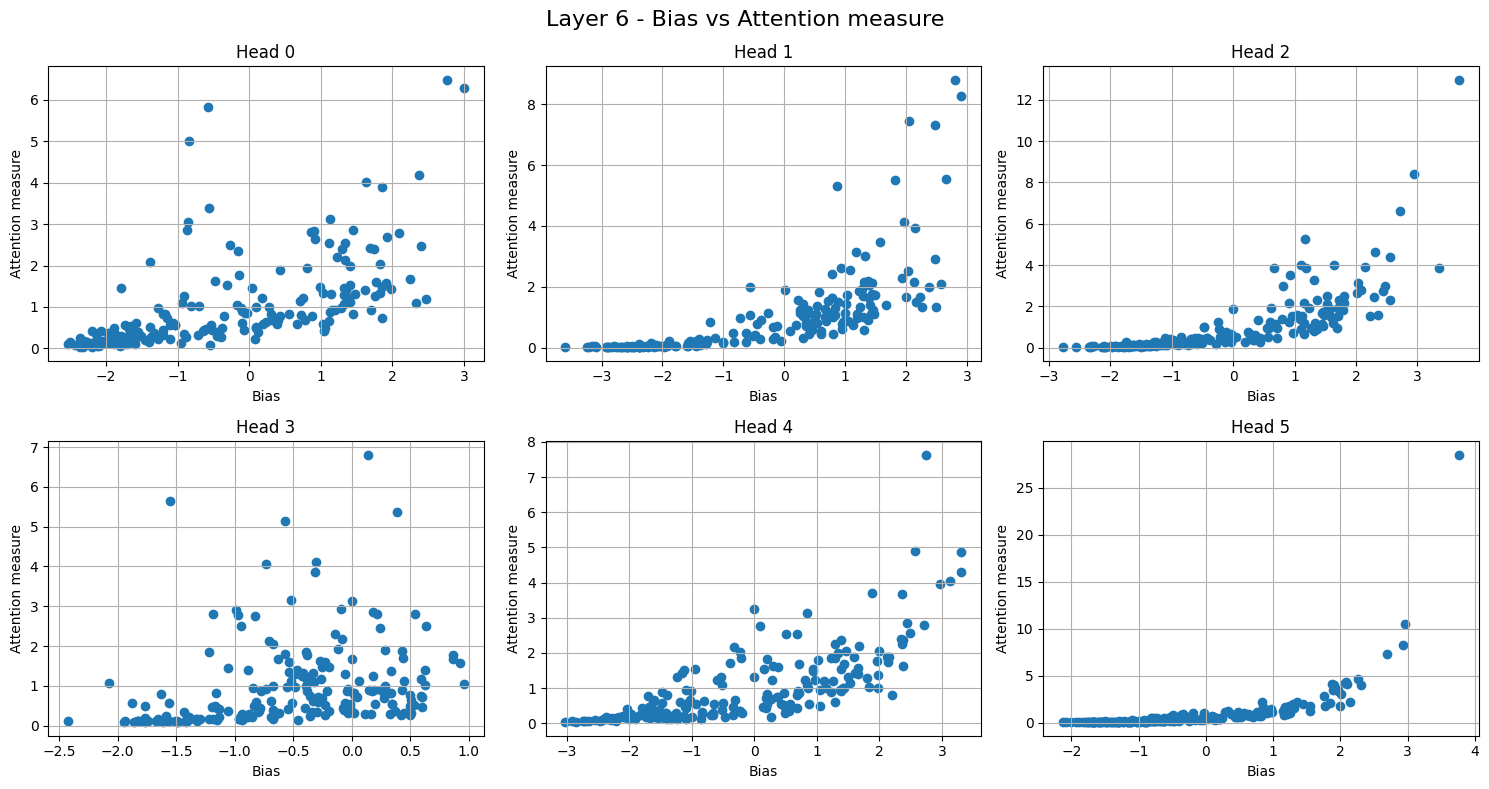

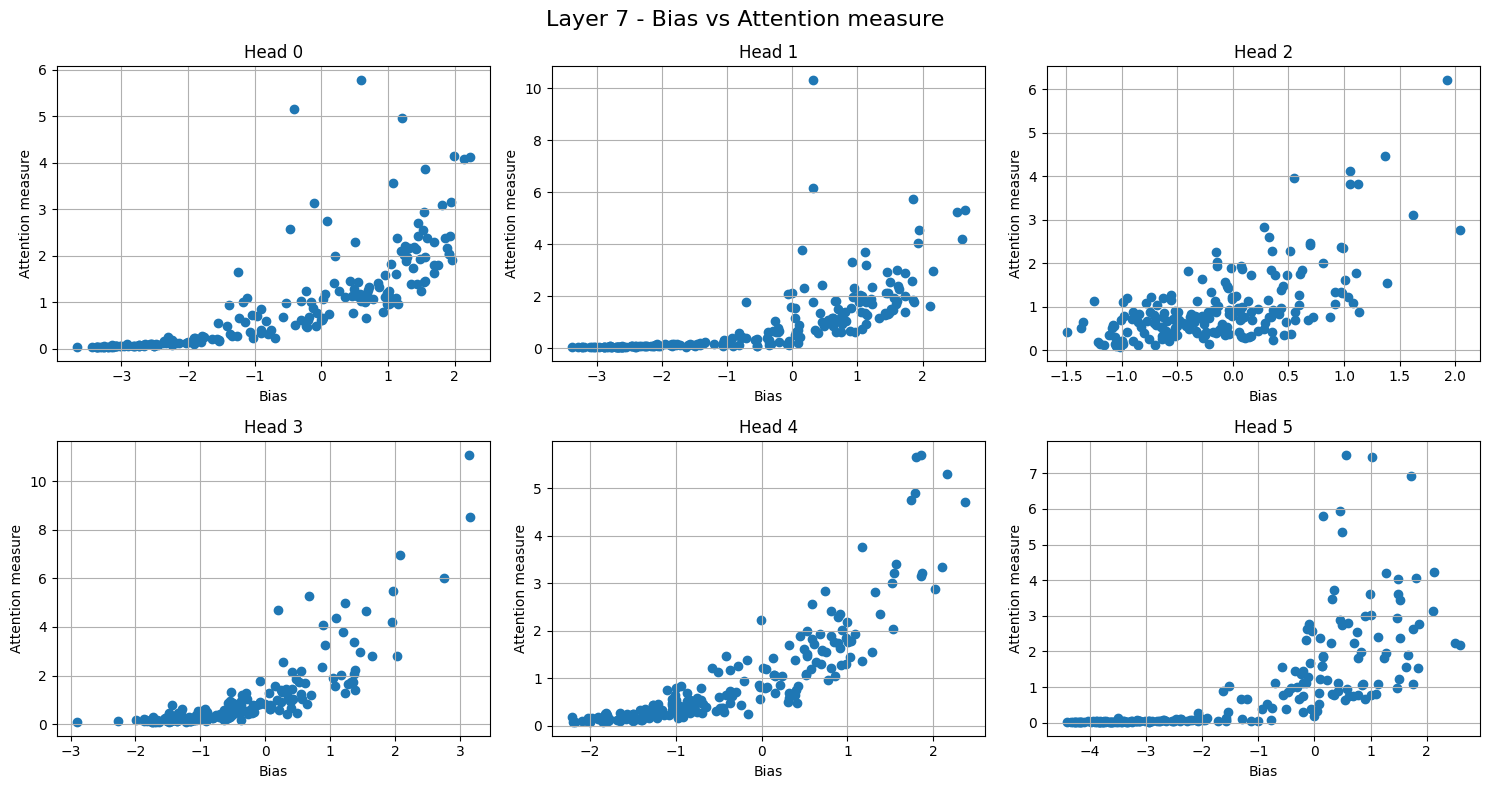

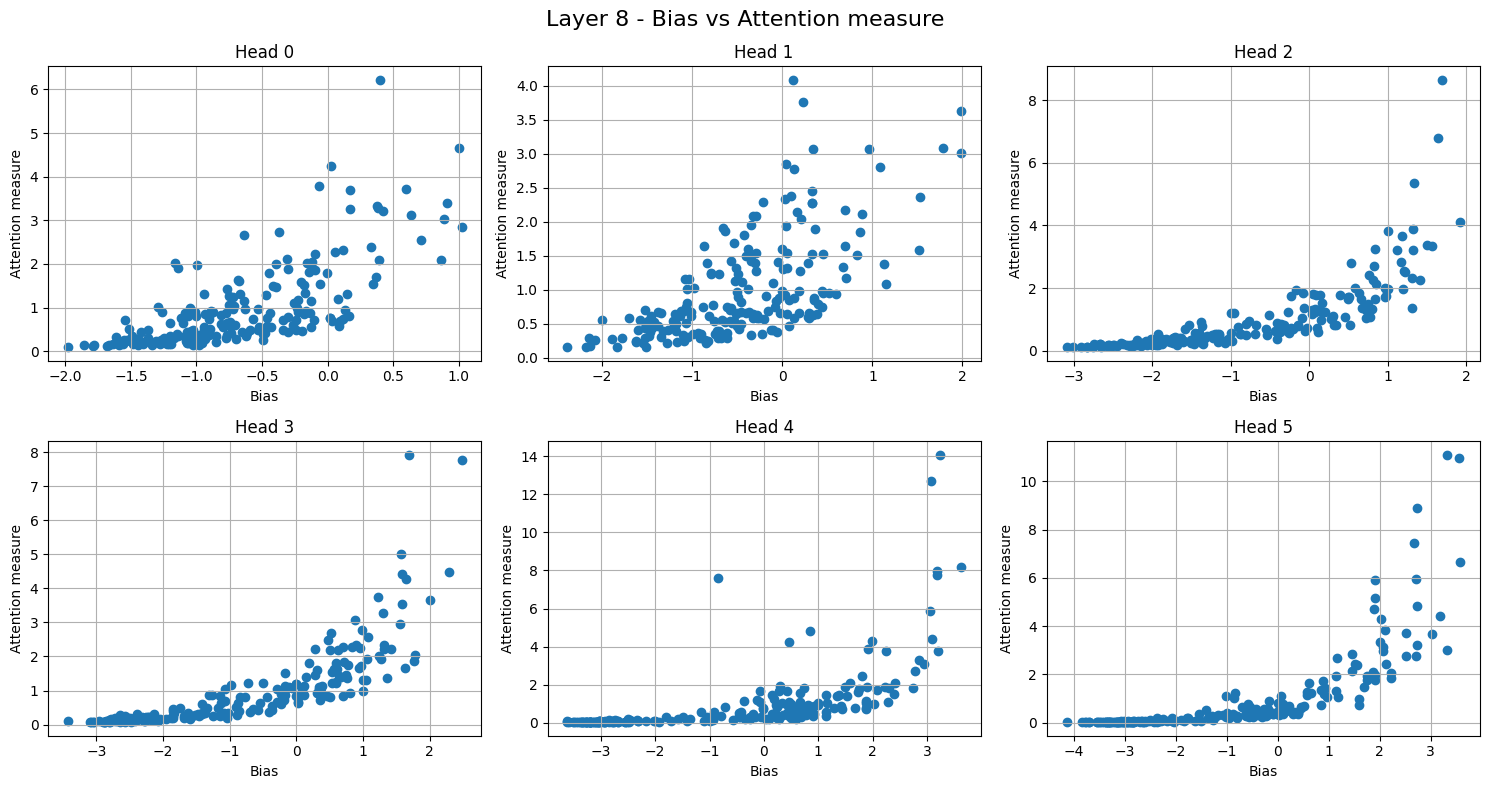

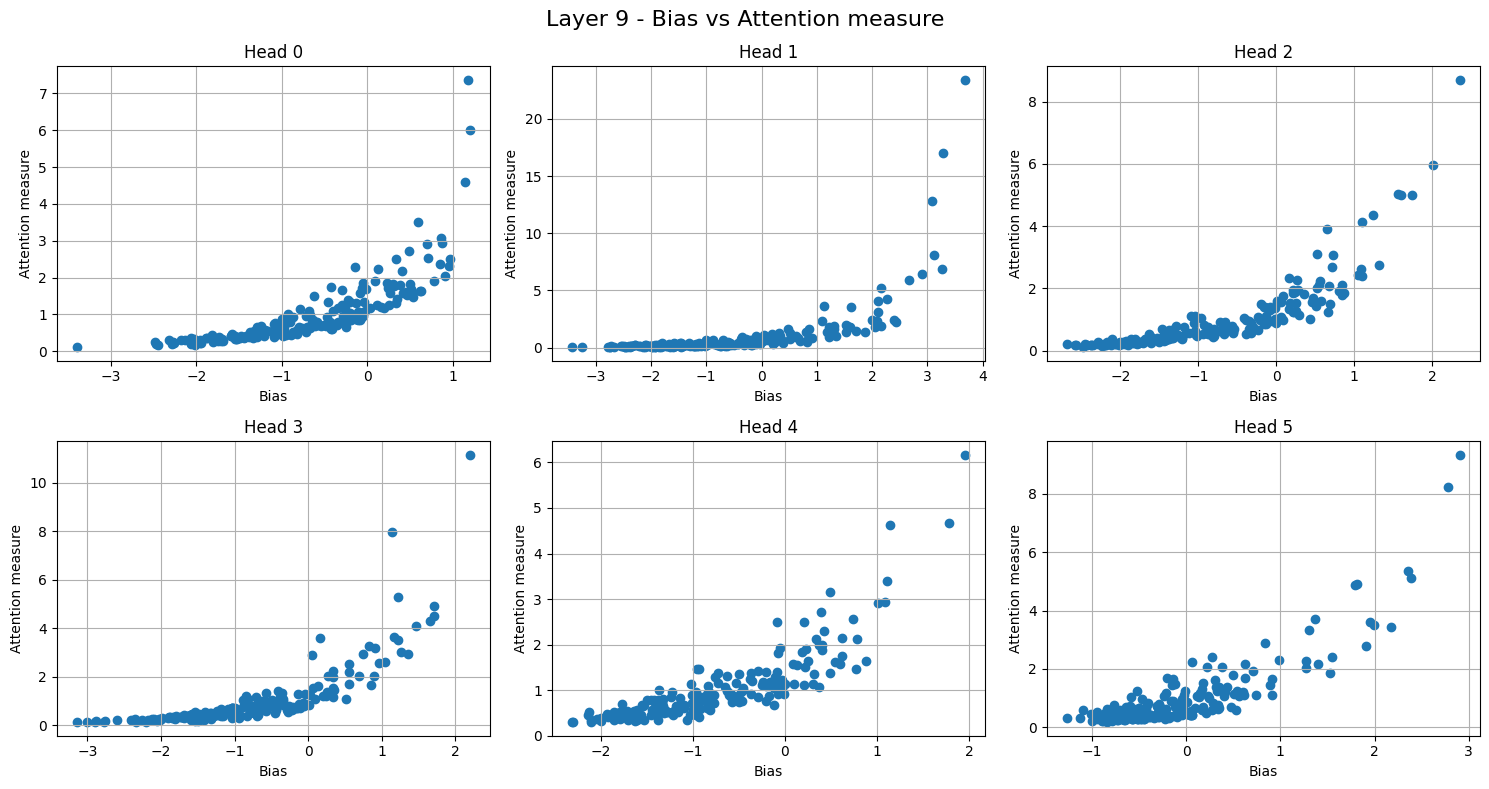

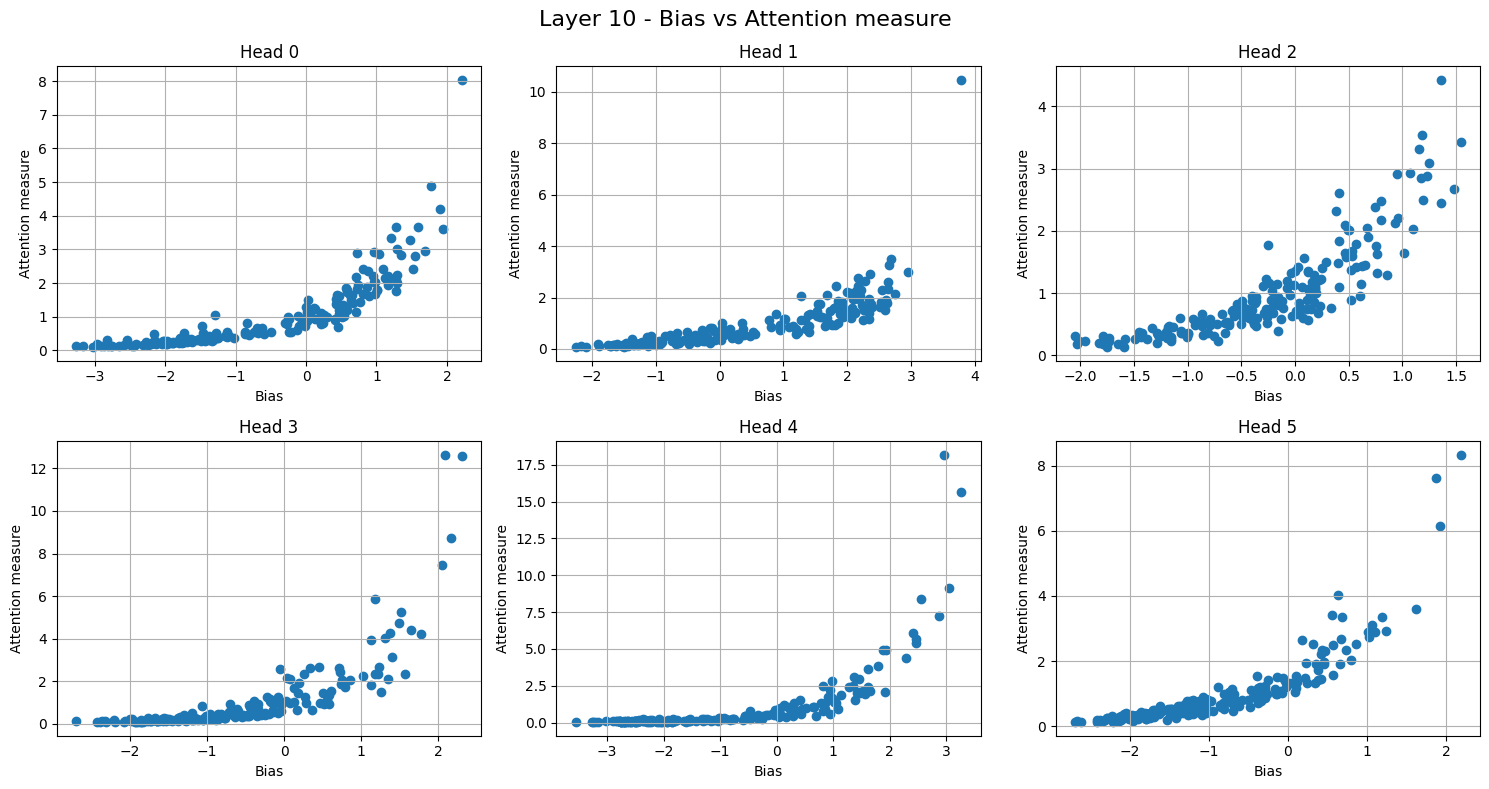

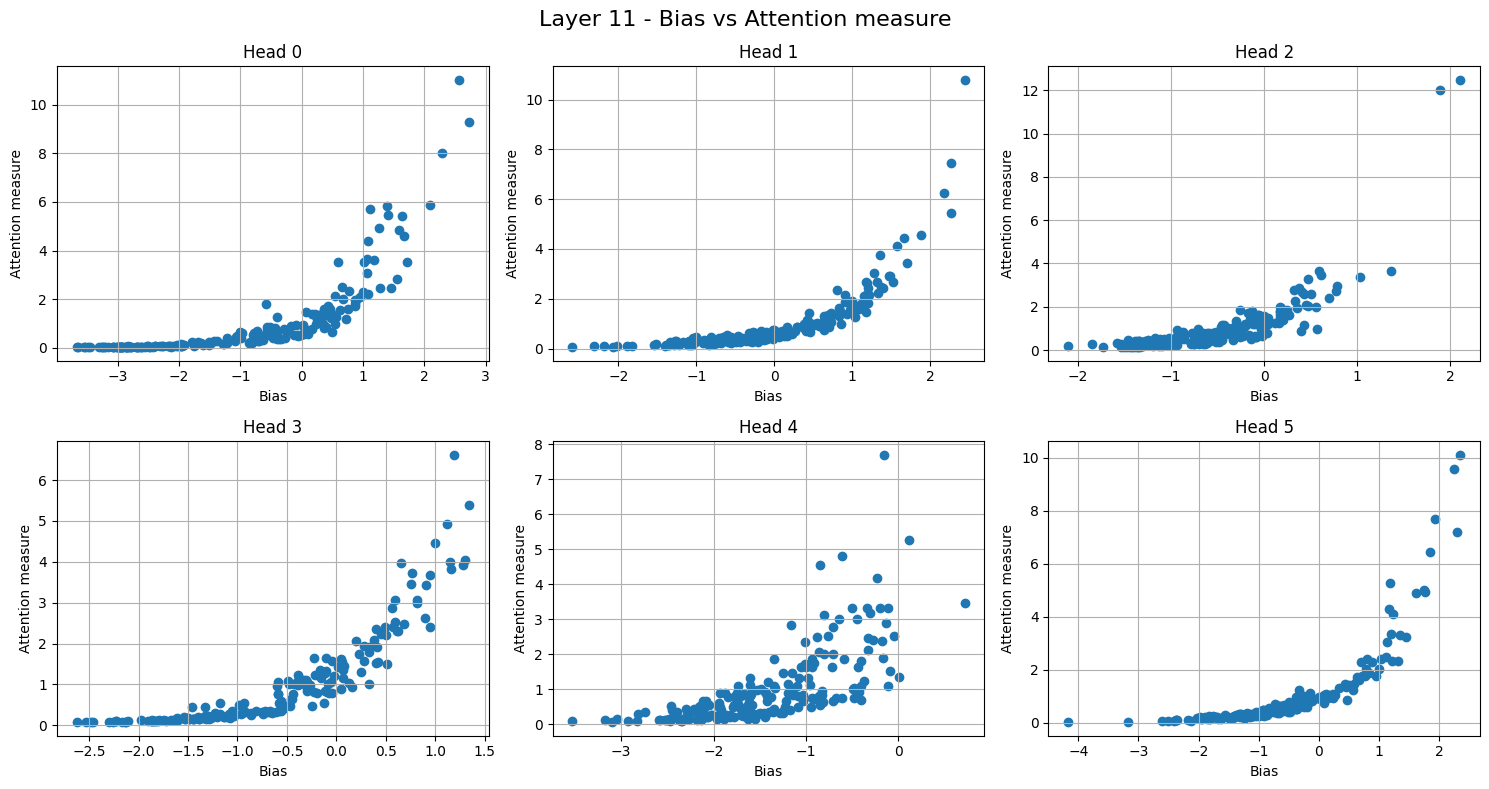

In [39]:
for i in range(len(attention_list)):
    num_layer = i
    attention_at_layer = attention_list[num_layer][0]
    b_at_layer = b_list[num_layer][0]

    n_heads = attention_at_layer.shape[0]  # nombre de têtes
    rows, cols = 2, 3  # grille 2x3

    plt.figure(figsize=(15, 8))  # taille globale de la figure
    plt.suptitle(f"Layer {num_layer} - Bias vs Attention measure", fontsize=16)

    for head in range(n_heads):
        b_head = b_at_layer[:, head]
        attention_map_head = attention_at_layer[head, :, :]
        attention_measure_head = attention_map_head.sum(dim=0)  # somme des poids d'attention pour chaque token

        plt.subplot(rows, cols, head + 1)  # position dans la grille
        plt.scatter(b_head.cpu(), attention_measure_head.cpu())
        plt.title(f"Head {head}")
        plt.xlabel("Bias")
        plt.ylabel("Attention measure")
        plt.grid(True)

    plt.tight_layout()  # ajuste les sous-figures pour éviter le chevauchement
    plt.show()